Start programu...
Plik CSV wczytany poprawnie.
Kształt danych: (26759, 13)
Zakodowane kolumny: ['driver_nationality', 'constructor_nationality']
Dane treningowe: (21407, 12)
Dane walidacyjne: (2676, 12)
Dane testowe: (2676, 12)
X_train: (21407, 11)
X_val: (2676, 11)
X_test: (2676, 11)
Rozkład klas w treningu:
top3
0    18689
1     2718
Name: count, dtype: int64
Rozkład klas w walidacji:
top3
0    2337
1     339
Name: count, dtype: int64
Rozkład klas w teście:
top3
0    2336
1     340
Name: count, dtype: int64


C:\Users\mateu\AppData\Local\Temp\ipykernel_3432\2149735128.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


Model wytrenowany.
Dokładność na zbiorze walidacyjnym: 0.8815396113602392
Dokładności predykcji (CV): [0.88206446 0.88323213 0.89114693 0.8918477  0.88834384]
Średnia dokładność (CV): 0.8873270125395758
AUC na zbiorze walidacyjnym: 0.8810087309070576
Dokładność na zbiorze testowym: 0.8841554559043349
AUC na zbiorze testowym: 0.891005867244158


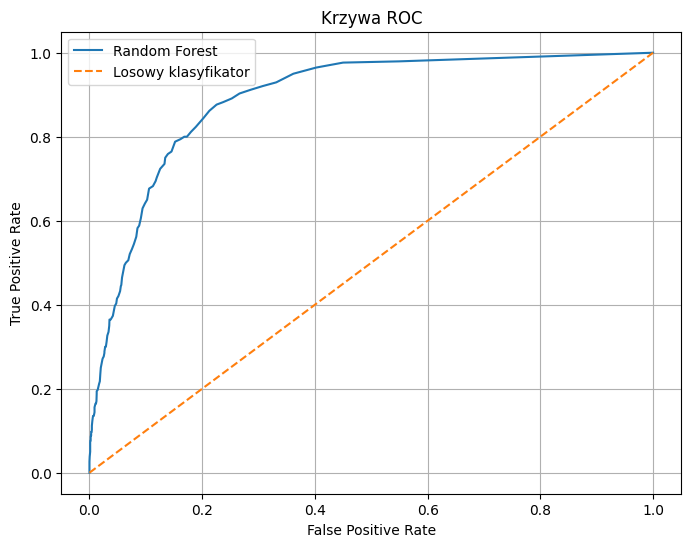


Najważniejsze cechy:
                      cecha  istotnosc
10           quali_position   0.171555
3                      grid   0.152466
8                driver_age   0.125134
0                    raceId   0.116952
6                 circuitId   0.085365
5                     round   0.080892
4                      year   0.070867
1                  driverId   0.069476
2             constructorId   0.065401
7        driver_nationality   0.041207
9   constructor_nationality   0.020685


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

print("Start programu...")

# =========================================================
# 1. Wczytanie danych
# =========================================================
df = pd.read_csv("f1_processed_dataset.csv")
print("Plik CSV wczytany poprawnie.")
print("Kształt danych:", df.shape)

# =========================================================
# 2. Usunięcie leakage
# =========================================================
if "positionOrder" in df.columns:
    df = df.drop(columns=["positionOrder"])

# =========================================================
# 3. Kodowanie zmiennych tekstowych
# =========================================================
target_col = "top3"

if target_col not in df.columns:
    raise ValueError(f"Brakuje kolumny docelowej: {target_col}")

df = df.dropna().copy()

label_encoders = {}
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if target_col in categorical_cols:
    categorical_cols.remove(target_col)

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Zakodowane kolumny:", categorical_cols)

# =========================================================
# 4. Losowy podział: 80% train, 10% validation, 10% test
# =========================================================
# Najpierw oddzielamy 20% na część tymczasową
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=1, stratify=df[target_col]
)

# Z tych 20% dzielimy po równo na validation i test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=1, stratify=temp_df[target_col]
)

print("Dane treningowe:", train_df.shape)
print("Dane walidacyjne:", val_df.shape)
print("Dane testowe:", test_df.shape)

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col].astype(int)

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col].astype(int)

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Rozkład klas w treningu:")
print(y_train.value_counts())
print("Rozkład klas w walidacji:")
print(y_val.value_counts())
print("Rozkład klas w teście:")
print(y_test.value_counts())

# =========================================================
# 5. Budowa modelu Random Forest
# =========================================================
Las = RandomForestClassifier(n_estimators=100, random_state=1)
Las.fit(X_train, y_train)
print("Model wytrenowany.")

# =========================================================
# 6. Ocena na zbiorze walidacyjnym
# =========================================================
y_val_pred = Las.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print("Dokładność na zbiorze walidacyjnym:", val_accuracy)

# =========================================================
# 7. Cross-validation na zbiorze treningowym
# =========================================================
scores_ = cross_val_score(Las, X_train, y_train, cv=5)
print("Dokładności predykcji (CV):", scores_)
print("Średnia dokładność (CV):", scores_.mean())

# =========================================================
# 8. Dopasowanie najlepszego progu / podgląd ROC na walidacji
# =========================================================
y_val_prob = Las.predict_proba(X_val)[:, 1]
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob)
val_auc = roc_auc_score(y_val, y_val_prob)
print("AUC na zbiorze walidacyjnym:", val_auc)

# =========================================================
# 9. Ostateczna ocena na zbiorze testowym
# =========================================================
y_test_prob = Las.predict_proba(X_test)[:, 1]
y_test_pred = Las.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Dokładność na zbiorze testowym:", test_accuracy)
print("AUC na zbiorze testowym:", test_auc)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)

# =========================================================
# 10. Krzywa ROC
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label="Random Forest")
plt.plot([0, 1], [0, 1], "--", label="Losowy klasyfikator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 11. Ważność cech
# =========================================================
feature_importances = pd.DataFrame({
    "cecha": X_train.columns,
    "istotnosc": Las.feature_importances_
}).sort_values(by="istotnosc", ascending=False)

print("\nNajważniejsze cechy:")
print(feature_importances)


